# Q : 1
### Create a random 4×3 matrix and perform SVD using NumPy.
### Verify matrix reconstruction using the top two singular values.

In [3]:
import numpy as np
A = np.random.rand(4,3)
print("Original Matrix A : \n",A)

Original Matrix A : 
 [[0.26899884 0.14065245 0.47738164]
 [0.52393333 0.00261463 0.26846829]
 [0.16484055 0.72104147 0.82581095]
 [0.7690261  0.4113647  0.41005271]]


In [7]:
U,S,VT = np.linalg.svd(A)

k = 2 
U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = VT[:k, :]


In [10]:
A_reconstructed = U_k @ S_k @ VT_k
print("\nReconstructed Matrix (Top 2 Singular Values):\n", A_reconstructed)


Reconstructed Matrix (Top 2 Singular Values):
 [[0.29169088 0.26914159 0.36427934]
 [0.53773836 0.08078288 0.19966085]
 [0.16256845 0.7081762  0.83713557]
 [0.75081497 0.30824784 0.50082112]]


In [11]:
error = np.linalg.norm(A - A_reconstructed)
print("\nReconstruction Error:", error)


Reconstruction Error: 0.24567132079082918


# Q.2

- Generate a synthetic dataset of two correlated features. Plot the scatter plot.
- Compute the covariance matrix and find eigenvalues/eigenvectors.
- Perform PCA manually: project the dataset onto the first principal component.
- Perform PCA using sklearn.decomposition.PCA on the Iris dataset (reduce to 2D). Visualize clusters.

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

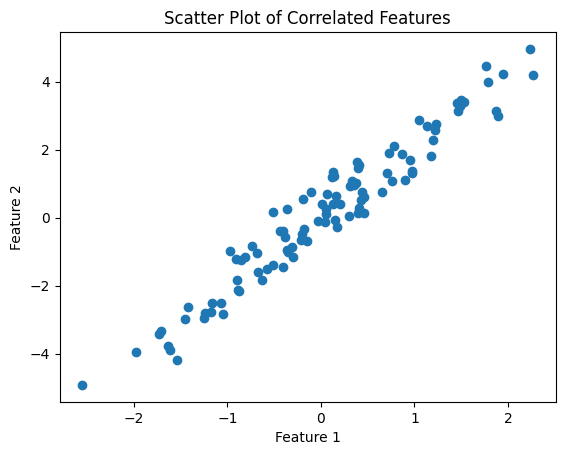

In [13]:
np.random.seed(0)

x = np.random.randn(100)
y = 2 * x + np.random.randn(100) * 0.5  

data = np.vstack((x, y)).T

plt.scatter(x, y)
plt.title("Scatter Plot of Correlated Features")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [14]:
cov_matrix = np.cov(data.T)
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[1.02608749 2.1110203 ]
 [2.1110203  4.61006856]]


In [15]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)


Eigenvalues:
 [0.04902823 5.58712782]
Eigenvectors:
 [[-0.90751033 -0.42002977]
 [ 0.42002977 -0.90751033]]


In [17]:
pc1 = eigenvectors[:, np.argmax(eigenvalues)]
projected_data = data @ pc1

print("Projected Data (first 5 values):\n", projected_data[:5])


Projected Data (first 5 values):
 [-4.79723529 -0.28281891 -1.61103962 -5.44837805 -3.64177547]


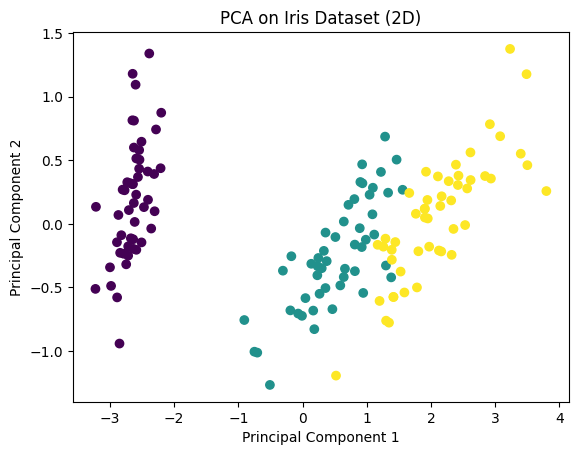

In [18]:
iris = load_iris()
X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA on Iris Dataset (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Q : 3
- Use the Iris dataset. Select only two classes (binary).
- Compute the class means, within-class scatter plot, and between-class scatter plot.
- Derive the projection vector (w) for LDA manually.
- Apply sklearn.discriminant_analysis.LinearDiscriminantAnalysis on the full Iris dataset (three classes). Visualize the 2D projection

In [19]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [21]:
iris = load_iris()
x = iris.data 
y = iris.target

In [22]:
X_binary = X[y != 2]
y_binary = y[y != 2]


In [23]:
X0 = X_binary[y_binary == 0]
X1 = X_binary[y_binary == 1]

mean0 = np.mean(X0, axis=0)
mean1 = np.mean(X1, axis=0)

print("Mean of Class 0 : \n",mean0)
print("Mean of Class 1 : \n",mean1)

Mean of Class 0 : 
 [5.006 3.428 1.462 0.246]
Mean of Class 1 : 
 [5.936 2.77  4.26  1.326]


In [24]:
Sw = np.zeros((4,4))

for x in X0:
    diff = (x - mean0).reshape(4,1)
    Sw += diff @ diff.T

for x in X1:
    diff = (x - mean1).reshape(4,1)
    Sw += diff @ diff.T

print("Within-class Scatter Matrix:\n", Sw)

Within-class Scatter Matrix:
 [[19.1434  9.0356  9.7634  3.2394]
 [ 9.0356 11.8658  4.6232  2.4746]
 [ 9.7634  4.6232 12.2978  3.8794]
 [ 3.2394  2.4746  3.8794  2.4604]]


In [25]:
mean_diff = (mean0 - mean1).reshape(4,1)
Sb = mean_diff @ mean_diff.T

print("Between-class Scatter Matrix:\n", Sb)


Between-class Scatter Matrix:
 [[ 0.8649   -0.61194   2.60214   1.0044  ]
 [-0.61194   0.432964 -1.841084 -0.71064 ]
 [ 2.60214  -1.841084  7.828804  3.02184 ]
 [ 1.0044   -0.71064   3.02184   1.1664  ]]


In [26]:
w = np.linalg.inv(Sw) @ (mean0 - mean1)

print("Projection Vector w:\n", w)

Projection Vector w:
 [ 0.03115072  0.18390775 -0.22210403 -0.31473638]


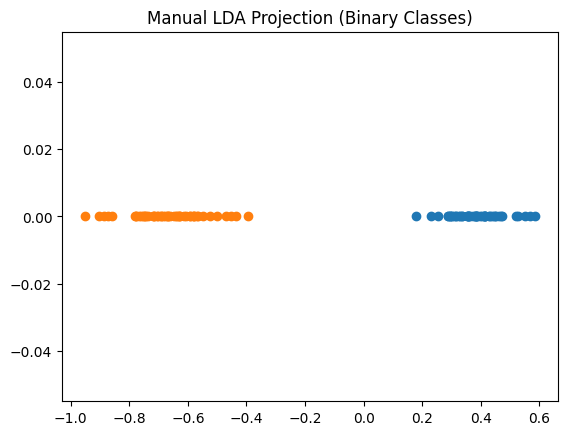

In [27]:
X_projected = X_binary @ w

# Scatter Plot
plt.scatter(X_projected[y_binary==0], np.zeros(len(X_projected[y_binary==0])))
plt.scatter(X_projected[y_binary==1], np.zeros(len(X_projected[y_binary==1])))
plt.title("Manual LDA Projection (Binary Classes)")
plt.show()

In [28]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

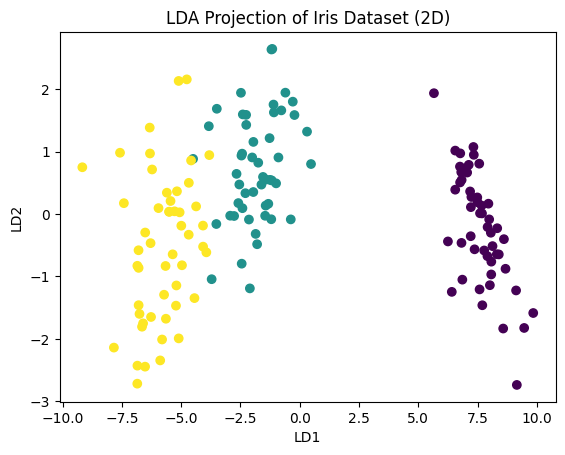

In [29]:
plt.scatter(X_lda[:,0], X_lda[:,1], c=y)
plt.title("LDA Projection of Iris Dataset (2D)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

!["Formula"](images/img.png)